---
title: "Lecture 1: Probability Axioms"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture1_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
        html-math-method: katex
    html: 
        code-fold: true
        embed-resources: true
        output-file: Lecture1
        code-links:
        - text: "Open in Colab"
          href: "https://colab.research.google.com/github/jamiehaddock/Math-151-Probability/blob/main/01_probability-axioms.ipynb"
          icon: "laptop"
    pdf:
        documentclass: article
        output-file: Lecture1
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: python3
colab:
  gh-user: "jamiehadd"   
  gh-repo: "Math-151-Probability" 
filters: 
  - input/remove-pause.lua
  - colab
execute:
  echo: true
  eval: true
---

In [1]:
# | echo: false

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

rng = np.random.default_rng(151)
plt.rcParams["figure.figsize"] = (6, 4)

# Why Study Probability?

Every day we deal with uncertainty: will it rain tomorrow, will a stock go up, will a treatment work for a given patient? **Probability** is the branch of mathematics that gives us preciselanguage for reasoning about this kind of uncertainty. This semester we'll build that language up from a handful of axioms, all the way to the tools used in statistics, machine learning, and randomized algorithms.

. . .

## Randomness is everywhere

Some randomness looks obviously random: the roll of a die or a shuffled deck of cards. But probability's reach goes far beyond games of chance -- it shows up any time we have incomplete information: election polling, sports outcomes, noisy sensor measurements, the spread of a disease through a population.

---

## Modeling deterministic phenomena probabilistically

Here's a subtler use of probability: modeling systems that are *not* fundamentally random at all, but whose governing deterministic mechanisms are so complex that treating them as random is the most useful thing we can do.

**Human height.** An individual's height is determined by genetics, nutrition, childhood health, and countless other factors -- in principle a (extremely complicated) deterministic function of a person's full biological and environmental history. Nobody could ever write that function down. But treat height as a random variable, and something remarkable happens: heights across a population follow a simple and predictable pattern (we'll give an explanation for *why* this happens when we meet the Central Limit Theorem in later weeks).

. . .

**Weather.** The atmosphere is governed by deterministic physical laws (e.g., the Navier-Stokes equations, thermodynamics). Yet weather is famously chaotic: two nearly-identical starting conditions can lead to wildly different outcomes just days later. A forecast of "70% chance of rain" is the scientifically honest way to communicate about these (in principle) deterministic but extremely complex physics.

---

## Randomness as a scientific and computational tool

Sometimes we *deliberately inject* randomness into the solution of a problem that is entirely deterministic, because the randomized approach turns out to be faster, simpler, or more robust than any deterministic method we know. This is the world of **randomized algorithms**. 

. . .

This idea -- using randomness as an algorithmic tool for deterministic problems -- is the theme of three running examples we'll use throughout this course, all coming from **randomized numerical linear algebra**: the randomized Kaczmarz method, randomized trace estimation, and randomized matrix multiplication. We'll get a first look at all three in the end of today's lecture, and we'll return to them as we build up more probability tools.

---

# A Word on the Syllabus

A few highlights, and then let's pull up the full syllabus on Canvas together:

- **Meetings:** Tuesdays and Thursdays 1:15-2:30pm (Shan 2440)
- **Office hours:** Tuesdays 5:30 - 6:30 pm, Thursdays 4 - 5 pm (Shan 2408)
- **Grading:** weekly homework via Gradescope (lowest score dropped), two in-class midterms, and an in-class final.
- **Text:** no required textbook -- lectures primarily based on Introduction to Probability by Bertsekas and Tsitsiklis, Introduction to Probability by Blitzstein and Hwang, and Introduction to Probability for Computing by Harchol-Balter.
- **Python:** we'll use it throughout to illustrate ideas with simulations. No prior programming experience is necessary.

. . .

::: {.callout-tip icon=false}
## Note
Full policies, the tentative week-by-week schedule, and links to Gradescope all live on our Canvas page -- let's hop over there now.
:::

---

# Probabilistic Models

A **probabilistic model** is a mathematical description of an experiment or an uncertain situation. Every probabilistic model has two main ingredients: the sample space and the probabilistic law. We'll explore one running example today: **rolling a fair six-sided die**.

![](figs/probabilistic_model.jpeg){width=500}

---

::: {.callout-note icon=false}
## Definition: Sample space
The **sample space** $\Omega$ of an experiment is the set of *all possible outcomes*. Each element $\omega \in \Omega$ is a single, complete, fully-specified result of the experiment.
:::

**Running example:** for one roll of a fair six-sided die, $$\Omega = \{1, 2, 3, 4, 5, 6\}.$$

. . .

::: {.callout-note icon=false}
## Definition: Event
An **event** is a subset $A \subseteq \Omega$: a collection of outcomes that we group together because we care whether *one of them* occurred.
:::

**Running example:** $A = \{\text{roll is even}\} = \{2,4,6\}$. &nbsp; $B = \{\text{roll is at least } 5\} = \{5,6\}$.

---

::: {.callout-note icon=false}
## Definition: Probability law
A **probability law** (or probability measure) $P$ assigns to every event $A \subseteq \Omega$ a number $P(A)$, called the *probability of* $A$, subject to a short list of axioms we'll state soon.
:::

. . .

## Visualizing a sample space and an event

A standard way to picture a particular discrete probabilistic model is as a set of points (the sample space), with an event drawn as a highlighted subset of those points. Below is that picture for the experiment of rolling **two** dice: the sample space has 36 equally-likely points, and we've circled the event $A = \{\text{the two rolls sum to } 7\}$.

![](figs/tworolls=7.jpeg){width=500}

---

# Choosing a Good and Valid Sample Space

First, note that the probabilistic model is a choice, and some choices can be better and some can be worse.

___

**Running example:** for one roll of a fair six-sided die, we could define $$\Omega = \{1, 2, 3, 4, 5, 6\}$$ or $$\Omega = \{1, 2, 3, 4, 5, 6, 7, \pi\}.$$ While valid, the second option includes *irrelevant* elements.  We could also define $$\Omega = \{1R, 1NR, 2R, 2NR, 3R, 3NR, 4R, 4NR, 5R, 5NR, 6R, 6NR\}$$ where R and NR indicate whether the day the dice was rolled was rainy or not rainy.  While valid, this option does not include the appropriate *granularity* for the measurement of interest (the dice outcome).

. . .

Appropriate granularity and no irrelevant elements make a *good* sample space.  There are properties of the sample space that must hold for it to be *valid*.  Not just any list of "outcomes" makes a valid sample space. A valid sample space has two essential properties.

---

## Mutually exclusive

::: {.callout-note icon=false}
## Definition: Mutually exclusive
The elements of $\Omega$ must be **mutually exclusive**: on any run of the experiment, *exactly one* element of $\Omega$ occurs.
:::

**Why this matters -- our dice example.** Suppose we (incorrectly) tried building a sample space for one die roll out of *overlapping* descriptions, say $$\Omega' = \{\text{``even"},\ \text{``odd"},\ \text{``greater than 3"}\}.$$ Roll a 4: the outcome is *simultaneously* "even" **and** "greater than 3" -- two elements of $\Omega'$ occur at once! We can no longer unambiguously ask "which point of $\Omega'$ occurred," and (as we'll see in a moment) the additivity axiom is meaningless when the pieces we're adding up aren't disjoint.

. . .

::: {.callout-tip icon=false}
## Note
This is exactly why we insist $\Omega = \{1,2,3,4,5,6\}$: each number is a distinct, non-overlapping outcome. "Even" and "greater than 3" are perfectly good **events** -- $\{2,4,6\}$ and $\{4,5,6\}$ -- built *out of* these elementary outcomes. They just aren't themselves elements of $\Omega$.
:::

---

## Collectively exhaustive

::: {.callout-note icon=false}
## Definition: Collectively exhaustive
The elements of $\Omega$ must be **collectively exhaustive**: *every* possible outcome of the experiment is represented by some element of $\Omega$.
:::

**Running example:** If we forgot to include 6 and used $\Omega'' = \{1,2,3,4,5\}$, a roll landing on 6 would correspond to *no point at all* in $\Omega''$ -- the model has no way to talk about it, and $P(\Omega'')$ doesn't equal 1 for a fair die (which will also contradict the axioms we'll see momentarily).

. . .

::: {.callout-warning icon=false}
## Fact
Mutually exclusive and collectively exhaustive together mean that every trial of the experiment corresponds to *exactly one* point of $\Omega$.
:::

---

# The Probability Axioms

Once we've fixed a sample space, **Kolmogorov's axioms** define a legitimate probability law. 

. . .

::: {.callout-warning icon=false}
## Axiom 1 -- Nonnegativity
$$P(A) \geq 0 \quad \text{for every event } A \subseteq \Omega.$$
:::

**Running example:** $P(\{4\}) = \tfrac16 \geq 0$. 

---

::: {.callout-warning icon=false}
## Axiom 2 -- (Finite and Countable) Additivity
If $A$ and $B$ are **disjoint** events ($A \cap B = \emptyset$), then $$P(A \cup B) = P(A) + P(B).$$ More generally, for pairwise disjoint $A_1, A_2, \ldots$: $P\!\left(\bigcup_i A_i\right) = \sum_i P(A_i)$.
:::

**Running example:** $\{2\}, \{4\}, \{6\}$ are pairwise disjoint, and their union is $A=\{2,4,6\}$, so $$P(A) = P(\{2\})+P(\{4\})+P(\{6\}) = \tfrac16+\tfrac16+\tfrac16 = \tfrac12.$$ Notice this is exactly why mutual exclusivity in the sample space mattered a moment ago: additivity only makes sense when the outcomes don't overlap.

. . .

::: {.callout-warning icon=false}
## Axiom 3 -- Normalization
$$P(\Omega) = 1.$$
:::

**Running example:** $P(\{1,2,3,4,5,6\}) = 1$ -- *something* always happens on a roll. 

---

# Consequences of the Axioms

From just these three rules, we can derive a whole toolkit of useful facts.

---

::: {.callout-warning icon=false}
## Theorem: Monotonicity
If $A \subseteq B$, then $P(A) \le P(B)$.
:::

<details><summary>Proof:</summary>
Since $A \subseteq B$, we can write $B$ as the disjoint union $B = A \cup (B \setminus A)$. By Axiom 2 (additivity), $$P(B) = P(A) + P(B\setminus A).$$ By Axiom 1 (nonnegativity), $P(B\setminus A) \geq 0$, so $P(B) \geq P(A)$. $\blacksquare$
</details>

**Running example:** $A=\{2,4\} \subseteq B=\{2,4,6\}$: $P(A)=\tfrac13 \le P(B) = \tfrac12$. &#10003;

---

::: {.callout-warning icon=false}
## Theorem: Complement Rule
$$P(A^c) = 1 - P(A).$$
:::

<details><summary>Proof:</summary>
$A$ and $A^c$ are disjoint, and $A \cup A^c = \Omega$. By additivity and normalization, $$1 = P(\Omega) = P(A \cup A^c) = P(A) + P(A^c),$$ so $P(A^c) = 1-P(A)$. $\blacksquare$
</details>

**Running example:** $A=\{2,4,6\}$, $P(A)=\tfrac12$; $A^c=\{1,3,5\}$, $P(A^c)=\tfrac12 = 1-\tfrac12$. &#10003;

---

::: {.callout-warning icon=false}
## Theorem: Inclusion-Exclusion
$$P(A \cup B) = P(A) + P(B) - P(A\cap B).$$
:::

<details><summary>Proof:</summary>
Decompose $A \cup B$ into the disjoint pieces $A$ and $B\setminus A$, and decompose $B$ into the disjoint pieces $A\cap B$ and $B\setminus A$. Additivity gives $P(B) = P(A\cap B) + P(B\setminus A),$ i.e. $P(B\setminus A) = P(B) - P(A \cap B)$. Substituting, $$P(A\cup B) = P(A) + P(B\setminus A) = P(A) + P(B) - P(A\cap B). \qquad \blacksquare$$
</details>

Here's the picture behind that proof: shading shows $B\setminus A$, the piece of $B$ we add to $A$ once we've removed the double-counted overlap.

![](figs/inclusion_exclusion.jpeg){width=500}

---

**Dice check:** $A=\{\text{even}\}=\{2,4,6\}$, $B=\{\ge 4\}=\{4,5,6\}$, $A\cap B=\{4,6\}$. Direct count: $A\cup B=\{2,4,5,6\}$, so $P(A\cup B)=\tfrac46=\tfrac23$. Formula: $\tfrac12+\tfrac12-\tfrac13 = \tfrac23$. &#10003;

---

::: {.callout-warning icon=false}
## Theorem: Union Bound
$$P(A \cup B) \le P(A) + P(B).$$
:::

<details><summary>Proof:</summary>
Immediate from Inclusion-Exclusion: $P(A\cup B) = P(A)+P(B) - P(A\cap B) \le P(A)+P(B)$, since $P(A\cap B)\geq 0$ by nonnegativity. $\blacksquare$
</details>

**Running example:** $P(A\cup B)=\tfrac23 \le P(A)+P(B) = 1$. &#10003; (Loose here, since $A,B$ overlap a lot -- the bound is tightest when $A,B$ barely overlap.)

---

::: {.callout-warning icon=false}
## Theorem: Three-Event Decomposition
$$P(A\cup B\cup C) = P(A) + P(A^c\cap B) + P(A^c\cap B^c\cap C).$$
:::

<details><summary>Proof:</summary>
We disjointify $A\cup B\cup C$ into three pieces: $A$ itself, the part of $B$ not already in $A$ (i.e. $A^c\cap B$), and the part of $C$ not already in $A$ or $B$ (i.e. $A^c\cap B^c\cap C$).

*These three sets are pairwise disjoint:* the second requires $\notin A$, so it can't overlap the first; the third requires $\notin A$ and $\notin B$, so it can't overlap the first (needs $\notin A$) or the second (needs $\notin B$).

*Their union is exactly $A\cup B\cup C$:* if $x \in A$, it's captured by the first piece. If $x\notin A$ but $x\in B$, it's captured by the second. If $x \notin A, x\notin B$, but $x\in C$, it's captured by the third. Every $x \in A\cup B\cup C$ falls into exactly one case.

Since the three pieces are disjoint with union $A\cup B\cup C$, additivity (applied twice) gives the result. $\blacksquare$
</details>

A three-circle Venn diagram for reference (the same disjointification trick works no matter how the circles overlap):

![](figs/three_event_decomposition.jpeg){width=500}

---

**Running example:** let $A=\{d_1=6\}$, $B=\{d_2=6\}$, $C=\{d_1+d_2=7\}$ on the 36-outcome sample space from earlier. Let's verify the decomposition by brute-force enumeration rather than by hand:

In [5]:
outcomes = [(i, j) for i in range(1, 7) for j in range(1, 7)]
A = {(i, j) for (i, j) in outcomes if i == 6}
B = {(i, j) for (i, j) in outcomes if j == 6}
C = {(i, j) for (i, j) in outcomes if i + j == 7}
Ac, Bc = set(outcomes) - A, set(outcomes) - B

union_direct = A | B | C
decomposition = A | (Ac & B) | (Ac & Bc & C)

print("P(A u B u C) direct        =", len(union_direct) / 36)
print("P(A) + P(Ac n B) + P(Ac n Bc n C) =",
      (len(A) + len(Ac & B) + len(Ac & Bc & C)) / 36)
print("Decomposition matches union:", union_direct == decomposition)

P(A u B u C) direct        = 0.4166666666666667
P(A) + P(Ac n B) + P(Ac n Bc n C) = 0.4166666666666667
Decomposition matches union: True


---

## A simulation check: Inclusion-Exclusion

Let's also verify Inclusion-Exclusion the way we'll verify many things this semester: by simulating many trials and comparing empirical frequencies to the formula.

In [6]:
n_trials = 200000
rolls = rng.integers(1, 7, size=n_trials)

A_event = (rolls % 2 == 0)          # even
B_event = (rolls >= 4)              # at least 4

p_A = A_event.mean()
p_B = B_event.mean()
p_AandB = (A_event & B_event).mean()
p_AorB_formula = p_A + p_B - p_AandB
p_AorB_direct = (A_event | B_event).mean()

print(f"P(A) ~ {p_A:.4f}   P(B) ~ {p_B:.4f}   P(A n B) ~ {p_AandB:.4f}")
print(f"P(A u B) via formula ~ {p_AorB_formula:.4f}")
print(f"P(A u B) direct      ~ {p_AorB_direct:.4f}")

P(A) ~ 0.4998   P(B) ~ 0.5017   P(A n B) ~ 0.3345
P(A u B) via formula ~ 0.6670
P(A u B) direct      ~ 0.6670


---

::: {.callout-caution icon=false}
## Exercise
Prove that $P(\emptyset) = 0$.
:::

<details><summary>Answer:</summary>
$\emptyset$ and $\Omega$ are disjoint (trivially -- $\emptyset$ has no elements to share), and $\emptyset \cup \Omega = \Omega$. By additivity, $$P(\Omega) = P(\emptyset \cup \Omega) = P(\emptyset) + P(\Omega).$$ Since $P(\Omega)=1$ is finite (Axiom 3), we may subtract it from both sides: $P(\emptyset) = 0$. $\blacksquare$
</details>

---

# Running Examples from Randomized Numerical Linear Algebra

To close today, let's get our first look at the three running examples we mentioned earlier. 

. . .

## Randomized Kaczmarz: solving Ax = b with a random twist

A **linear system** $Ax=b$ asks: given a matrix $A \in \mathbb{R}^{m\times n}$ and vector $b\in\mathbb{R}^m$, find $x$ satisfying all $m$ equations $a_i^\top x = b_i$ simultaneously (here $a_i \in \mathbb{R}^n$ is the $i$-th row of $A$). 

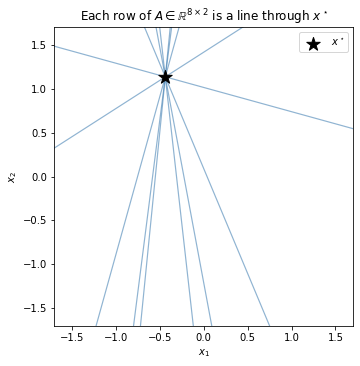

In [7]:
m, n = 8, 2
A = rng.normal(size=(m, n))
x_true = rng.normal(size=n)
b = A @ x_true

lim = 1.5 * max(1.0, np.max(np.abs(x_true)))
xs_line = np.linspace(-lim, lim, 200)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
for i in range(m):
    a_i, b_i = A[i], b[i]
    if abs(a_i[1]) > 1e-8:
        ys_line = (b_i - a_i[0] * xs_line) / a_i[1]
        ax.plot(xs_line, ys_line, color="steelblue", alpha=0.6, linewidth=1.2)
    else:
        ax.axvline(b_i / a_i[0], color="steelblue", alpha=0.6, linewidth=1.2)

ax.scatter(*x_true, color="black", marker="*", s=200, zorder=5, label=r"$x^\star$")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.set_title(r"Each row of $A \in \mathbb{R}^{8 \times 2}$ is a line through $x^\star$")
ax.legend()
ax.set_aspect("equal")
plt.show()

---

The classical **Kaczmarz method** solves this iteratively: start with a guess $x_0$, then repeatedly pick *one* equation (row) $i$ and project the current guess onto the hyperplane $\{x : a_i^\top x = b_i\}$ satisfying that single equation -- cycling through the rows in order.

The **randomized** idea: instead of cycling through rows in a fixed order, pick row $i$ *at random* with probability $p_i$ at each step. (We'll make "picked with probability $p_i$" fully precise once we've defined discrete probability distributions next week.)

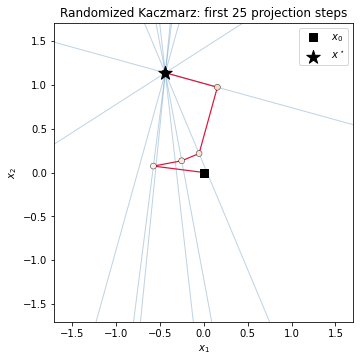

In [9]:
p = np.ones(m) / m  # all rows of A are equally likely to be chosen for the next projection step

x = np.zeros(n)
iterates = [x.copy()]
errors = [np.linalg.norm(x - x_true)]
for k in range(150):
    i = rng.choice(m, p=p)
    a_i, b_i = A[i], b[i]
    x = x + (b_i - a_i @ x) / (a_i @ a_i) * a_i
    iterates.append(x.copy())
    errors.append(np.linalg.norm(x - x_true))
iterates = np.array(iterates)

n_show = 25   # only show the first n_show steps -- it converges fast!

fig, ax = plt.subplots(figsize=(5.5, 5.5))
for i in range(m):
    a_i, b_i = A[i], b[i]
    if abs(a_i[1]) > 1e-8:
        ys_line = (b_i - a_i[0] * xs_line) / a_i[1]
        ax.plot(xs_line, ys_line, color="steelblue", alpha=0.35, linewidth=1.0, zorder=1)
    else:
        ax.axvline(b_i / a_i[0], color="steelblue", alpha=0.35, linewidth=1.0, zorder=1)

path = iterates[:n_show + 1]
ax.plot(path[:, 0], path[:, 1], color="crimson", linewidth=1.2, zorder=3)
ax.scatter(path[:, 0], path[:, 1], c=np.arange(len(path)), cmap="Reds", s=35,
           zorder=4, edgecolor="black", linewidth=0.4)
ax.scatter(*iterates[0], color="black", marker="s", s=70, zorder=5, label=r"$x_0$")
ax.scatter(*x_true, color="black", marker="*", s=200, zorder=5, label=r"$x^\star$")

ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.set_title(f"Randomized Kaczmarz: first {n_show} projection steps")
ax.set_aspect("equal")
ax.legend()
plt.show()

---

One of the beautiful things about the randomized Kaczmarz method is that, on average, the error of the methods converges to zero quickly!  (We can actually analyze this average error using only simple techniques from probability and linear algebra -- we'll do this later in the semester when we talk about functions of random variables and expectation!)

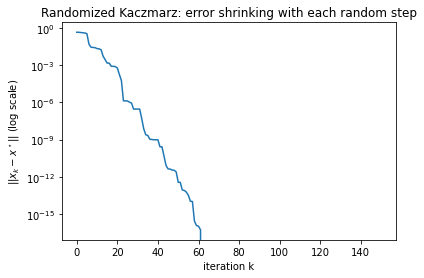

In [ ]:
plt.figure(figsize=(6, 4))
plt.semilogy(errors)
plt.xlabel("iteration k"); plt.ylabel(r"$||x_k - x^\star||$ (log scale)")
plt.title("Randomized Kaczmarz: error shrinking with each random step")
plt.show()

---

## Randomized trace estimation

The **trace** of a square matrix $A$ is the sum of its diagonal entries, $\operatorname{tr}(A) = \sum_i A_{ii} = \sum_i \mathbf{e}_i^\top A \mathbf{e}_i$ where $\mathbf{e}_i$ is the $i$th standard basis vector. For huge matrices that we only ever access *implicitly* (say, through a subroutine that computes $Av$ for a given vector $v$, never revealing individual entries -- common in machine learning and physics simulations), reading off diagonal entries directly may be impossible or extremely expensive.

---

The **randomized** idea: probe $A$ with a *random* vector $z$ (entries $\pm 1$, chosen independently by a fair coin flip) and compute $z^\top A z$. This single number is random, but its long-run average -- across many independent random probes -- turns out to equal $\operatorname{tr}(A)$ exactly. (We'll prove this precisely once we've met expectation and linearity!)

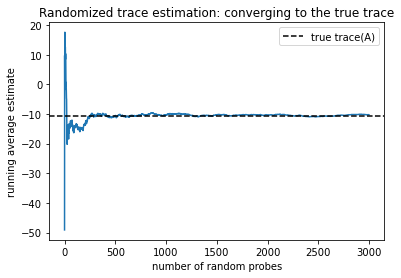

In [ ]:
n_ = 40
A = rng.normal(size=(n_, n_))
true_trace = np.trace(A)

def hutchinson_probe():
    z = rng.choice([-1, 1], size=n_)
    return z @ A @ z

estimates = np.array([hutchinson_probe() for _ in range(3000)])
running_mean = np.cumsum(estimates) / np.arange(1, len(estimates) + 1)

plt.plot(running_mean)
plt.axhline(true_trace, color="black", linestyle="--", label="true trace(A)")
plt.xlabel("number of random probes"); plt.ylabel("running average estimate")
plt.legend(); plt.title("Randomized trace estimation: converging to the true trace")
plt.show()

---

## Randomized matrix multiplication

Multiplying two large matrices $A\in\mathbb{R}^{n\times m}$ and $B\in\mathbb{R}^{m\times p}$ exactly costs roughly $n\cdot m\cdot p$ operations -- expensive when $m$ (the shared dimension) is huge. Notice that $$AB = \sum_{i=1}^m a_i b_i^\top,$$ a sum of $m$ simple rank-one pieces, where $a_i$ is a column of $A$ and $b_i^\top$ is a row of $B$.

---

The **randomized** idea: instead of summing *all* $m$ pieces, randomly sample just a few indices $i$ (again, more "important" pieces sampled more often) and average the corresponding rescaled pieces. The result is a cheap-to-compute *estimate* of $AB$ that's correct on average -- we'll see this later in the semester.

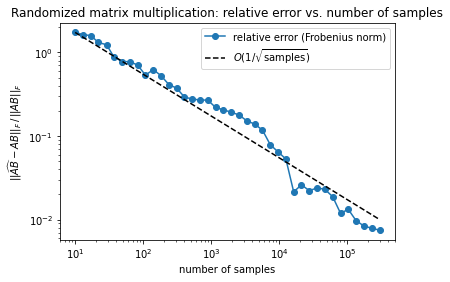

In [ ]:
n_, m_, p_ = 5, 50, 4
A = rng.normal(size=(n_, m_))
B = rng.normal(size=(m_, p_))
true_AB = A @ B

norms = np.linalg.norm(A, axis=0) * np.linalg.norm(B, axis=1)
p = norms / norms.sum()

def one_sample_estimate():
    i = rng.choice(m_, p=p)
    return np.outer(A[:, i], B[i, :]) / p[i]

N = 300000
samples = np.array([one_sample_estimate() for _ in range(N)])

# cumulative running average of the first k samples, for every k at once
cumulative_avg = np.cumsum(samples, axis=0) / np.arange(1, N + 1).reshape(-1, 1, 1)

# relative error (Frobenius norm) at a log-spaced grid of sample counts
sample_counts = np.unique(np.round(np.logspace(1, np.log10(N), 40)).astype(int))
fro_true = np.linalg.norm(true_AB, ord="fro")
rel_errors = [
    np.linalg.norm(cumulative_avg[k - 1] - true_AB, ord="fro") / fro_true
    for k in sample_counts
]

plt.figure(figsize=(6, 4))
plt.loglog(sample_counts, rel_errors, "o-", label="relative error (Frobenius norm)")
plt.loglog(sample_counts, rel_errors[0] * np.sqrt(sample_counts[0] / sample_counts),
           "k--", label=r"$O(1/\sqrt{\mathrm{samples}})$")
plt.xlabel("number of samples")
plt.ylabel(r"$||\widehat{AB} - AB||_F \,/\, ||AB||_F$")
plt.legend()
plt.title("Randomized matrix multiplication: relative error vs. number of samples")
plt.show()